# Pipeline completo: Preprocesamiento + Filtrado + Modelo

Este notebook implementa un pipeline end-to-end de Machine Learning:

1. **Preprocesamiento** (`BasePreprocess`): tratamiento de nulls, encoding, normalizacion, features polinomicas
2. **Filtrado de features** (`BaseFiltering`): eliminacion de features constantes, correlacionadas e irrelevantes
3. **Entrenamiento** del modelo (Random Forest)
4. **Evaluacion** completa con metricas: accuracy, precision, recall, F1, AUC-ROC

Ambas clases siguen el patron **fit/transform** para evitar data leakage:
- `fit()` aprende los parametros con datos de **train**
- `transform()` aplica esos parametros a **train** y **test**

## PASO 1: Preprocesamiento de datos

In [1]:
from src.preprocessing.base_preprocessing import BasePreprocess

# Instanciamos la clase de preprocesamiento.
# El fichero Excel contiene la lista de variables candidatas a ser predictoras.
base_pre = BasePreprocess("data/variables_withoutExperts.xlsx", "loan_status")

In [2]:
# fit(): aprende los parametros del preprocesamiento SOLO con datos de entrenamiento.
# Esto incluye: categorias del OHE, medianas para imputacion, parametros del QuantileTransformer, etc.
base_pre.fit("data/df_train_small.csv")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/src/preprocessing/base_preprocessing.py:62: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  self.train_X_data['earliest_cr_line'] = pd.to_datetime(self.train_X_data['earliest_cr_line'])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# transform(): aplica las transformaciones aprendidas en fit().
# Devuelve X_train (features) e y_train (target: True=default, False=fully paid).
X_train, y_train = base_pre.transform("data/df_train_small.csv")
print(f"Dimensiones tras preprocesamiento: {X_train.shape[0]} filas x {X_train.shape[1]} columnas")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/src/preprocessing/base_preprocessing.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_data['earliest_cr_line'] = pd.to_datetime(X_data['earliest_cr_line'])


Dimensiones tras preprocesamiento: 80000 filas x 2614 columnas


## PASO 2: Filtrado de features

`BaseFiltering` aplica 3 filtros secuenciales:
1. **DropConstantFeatures** (tol=0.9): elimina features donde el 90%+ de valores son iguales
2. **DropCorrelatedFeatures** (threshold=0.8): elimina una de cada par con correlacion > 0.8
3. **ProbeFeatureSelection** (n_probes=10): elimina features menos importantes que ruido aleatorio

In [4]:
from src.filtering.base_filtering import BaseFiltering

# Instanciamos el filtro con los parametros por defecto.
# Todos los parametros son configurables en el constructor.
base_filter = BaseFiltering(
    constant_tol=0.9,
    correlation_threshold=0.8,
    probe_n_probes=10,
    probe_scoring='roc_auc',
    probe_cv=3,
    probe_n_estimators=50,
    probe_max_depth=10
)

In [5]:
# fit(): aprende que features eliminar usando SOLO datos de train.
# Internamente ejecuta los 3 filtros en secuencia.
base_filter.fit(X_train, y_train)

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs

In [6]:
# Resumen del filtrado: cuantas features se eliminaron en cada paso.
base_filter.print_summary()

RESUMEN DEL PIPELINE DE FILTRADO
  Features iniciales:              2614
  Eliminadas cuasi-constantes:     -133
  Eliminadas por correlacion:       -1838
  Eliminadas por ProbeFeature:      -480
  Features seleccionadas finales:  163


In [7]:
# transform(): aplica los filtros aprendidos en fit() a los datos de train.
X_train_filtered = base_filter.transform(X_train)

print(f"Features seleccionadas ({X_train_filtered.shape[1]}):")
print(X_train_filtered.columns.tolist())

Features seleccionadas (163):
['home_ownership_MORTGAGE', 'verification_status_Not Verified', 'term_ 36 months', 'emp_title_00', 'emp_title_01', 'emp_title_02', 'emp_title_04', 'emp_title_06', 'emp_title_10', 'emp_title_13', 'loan_amnt', 'annual_inc', 'dti', 'loan_amnt annual_inc', 'loan_amnt dti', 'loan_amnt inq_last_6mths', 'loan_amnt mths_since_last_delinq', 'loan_amnt open_acc', 'loan_amnt revol_bal', 'loan_amnt revol_util', 'loan_amnt all_util', 'loan_amnt acc_open_past_24mths', 'loan_amnt avg_cur_bal', 'loan_amnt bc_open_to_buy', 'loan_amnt bc_util', 'loan_amnt mo_sin_old_il_acct', 'loan_amnt mo_sin_rcnt_rev_tl_op', 'loan_amnt mo_sin_rcnt_tl', 'loan_amnt mort_acc', 'loan_amnt mths_since_recent_bc', 'loan_amnt mths_since_recent_inq', 'loan_amnt num_actv_rev_tl', 'loan_amnt num_op_rev_tl', 'loan_amnt num_tl_op_past_12m', 'loan_amnt percent_bc_gt_75', 'loan_amnt total_bc_limit', 'loan_amnt earliest_cr_line_year', 'annual_inc dti', 'annual_inc inq_last_6mths', 'annual_inc mths_since_

## PASO 3: Entrenamiento del modelo

In [8]:
# Random Forest con class_weight='balanced' para tratar el desbalanceo de clases.
# balanced: asigna pesos inversamente proporcionales a la frecuencia de cada clase.
# Si Default es el 20%, su peso sera ~4x mayor que Fully Paid.

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_filtered, y_train.values.ravel())

train_accuracy = rf_model.score(X_train_filtered, y_train.values.ravel())
print(f"Modelo entrenado. Accuracy en TRAIN: {train_accuracy:.4f}")

Modelo entrenado. Accuracy en TRAIN: 1.0000


## PASO 4: Evaluacion en test

Aplicamos **exactamente** las mismas transformaciones al conjunto de test.
Usamos los objetos ya ajustados (fit) en train: `base_pre`, `base_filter`.

In [9]:
# 4.1 - Preprocesamiento del test (transform, NO fit)
X_test, y_test = base_pre.transform("data/df_test_small.csv")

# 4.2 - Filtrado del test (transform, NO fit)
X_test_filtered = base_filter.transform(X_test)

print(f"Dimensiones train filtrado: {X_train_filtered.shape}")
print(f"Dimensiones test filtrado:  {X_test_filtered.shape}")

/Users/mmartin/workspaces/education/cunef_ml_2026/modelizacion_datos_2026/src/preprocessing/base_preprocessing.py:135: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X_data['earliest_cr_line'] = pd.to_datetime(X_data['earliest_cr_line'])


Dimensiones train filtrado: (80000, 163)
Dimensiones test filtrado:  (20000, 163)


In [10]:
# 4.3 - Predicciones del modelo
# predict(): devuelve la clase predicha (True/False)
# predict_proba()[:,1]: devuelve la probabilidad de la clase positiva (Default)
class_predicted = rf_model.predict(X_test_filtered)
prob_predicted = rf_model.predict_proba(X_test_filtered)[:, 1]

## PASO 5: Metricas de evaluacion

En clasificacion binaria con clases desbalanceadas, **accuracy NO es suficiente**.
Un modelo que siempre prediga la clase mayoritaria tendria ~80% accuracy pero seria inutil.

Metricas clave:
- **Precision**: de los que predigo como default, cuantos realmente lo son?
- **Recall**: de todos los defaults reales, cuantos detecto?
- **F1-Score**: media armonica entre precision y recall
- **AUC-ROC**: capacidad de separar clases (independiente del umbral)

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import numpy as np

y_test_flat = y_test.values.ravel()

# 5.1 - Accuracy
test_accuracy = accuracy_score(y_test_flat, class_predicted)
print(f"Accuracy en TEST:  {test_accuracy:.4f}")
print(f"Accuracy en TRAIN: {train_accuracy:.4f}")
print(f"Diferencia (posible overfitting): {train_accuracy - test_accuracy:.4f}")

Accuracy en TEST:  0.8004
Accuracy en TRAIN: 1.0000
Diferencia (posible overfitting): 0.1996


In [12]:
# 5.2 - Classification Report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test_flat, class_predicted,
                            target_names=["Fully Paid (False)", "Default (True)"]))

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Fully Paid (False)       0.80      1.00      0.89     16003
    Default (True)       0.51      0.02      0.04      3997

          accuracy                           0.80     20000
         macro avg       0.66      0.51      0.46     20000
      weighted avg       0.74      0.80      0.72     20000



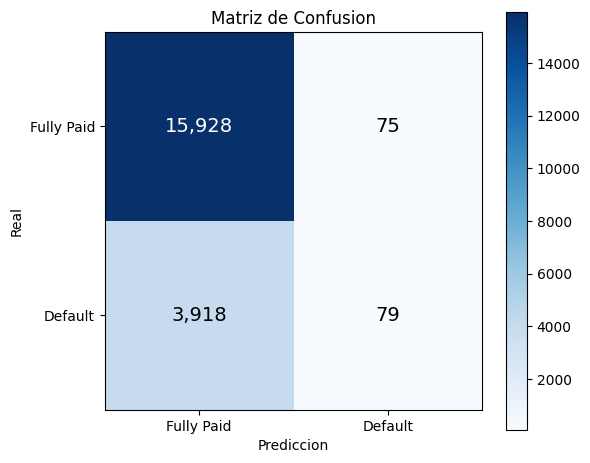


Verdaderos Negativos (TN): 15,928
Falsos Positivos (FP):     75
Falsos Negativos (FN):     3,918  <- Defaults no detectados
Verdaderos Positivos (TP): 79


In [13]:
# 5.3 - Matriz de Confusion
# TN = Fully Paid correctamente clasificados
# FP = Fully Paid clasificados como Default (error tipo I)
# FN = Default clasificados como Fully Paid (error tipo II) <- PELIGROSO en banca
# TP = Default correctamente clasificados

cm = confusion_matrix(y_test_flat, class_predicted)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Fully Paid", "Default"])
ax.set_yticklabels(["Fully Paid", "Default"])
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusion")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"\nVerdaderos Negativos (TN): {cm[0,0]:,}")
print(f"Falsos Positivos (FP):     {cm[0,1]:,}")
print(f"Falsos Negativos (FN):     {cm[1,0]:,}  <- Defaults no detectados")
print(f"Verdaderos Positivos (TP): {cm[1,1]:,}")

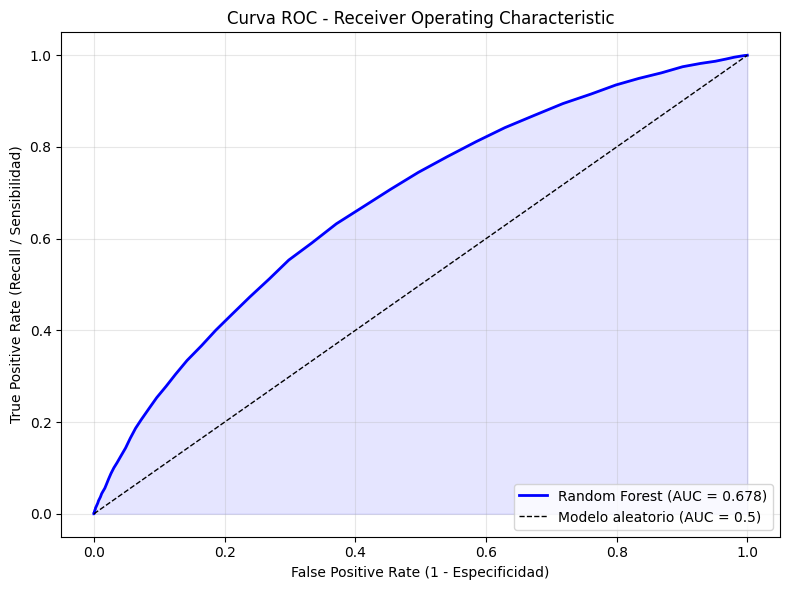


AUC-ROC: 0.6781


In [14]:
# 5.4 - Curva ROC y AUC
# La curva ROC muestra la capacidad del modelo para separar clases a diferentes umbrales.
# AUC = 1.0: perfecto | AUC = 0.5: aleatorio | AUC > 0.7: aceptable | AUC > 0.8: bueno

auc = roc_auc_score(y_test_flat, prob_predicted)
fpr, tpr, thresholds = roc_curve(y_test_flat, prob_predicted)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1, label="Modelo aleatorio (AUC = 0.5)")
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.xlabel('False Positive Rate (1 - Especificidad)')
plt.ylabel('True Positive Rate (Recall / Sensibilidad)')
plt.title('Curva ROC - Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC: {auc:.4f}")

In [15]:
# 5.5 - Resumen final de metricas
precision = precision_score(y_test_flat, class_predicted)
recall = recall_score(y_test_flat, class_predicted)
f1 = f1_score(y_test_flat, class_predicted)

print("=" * 60)
print("RESUMEN FINAL DE METRICAS (clase positiva = Default)")
print("=" * 60)
print(f"  Accuracy:   {test_accuracy:.4f}  (proporcion total de aciertos)")
print(f"  Precision:  {precision:.4f}  (de los que predigo default, cuantos lo son)")
print(f"  Recall:     {recall:.4f}  (de los defaults reales, cuantos detecto)")
print(f"  F1-Score:   {f1:.4f}  (equilibrio entre precision y recall)")
print(f"  AUC-ROC:    {auc:.4f}  (capacidad de separar clases)")
print("=" * 60)
print()
print("INTERPRETACION:")
print(f"  - El modelo tiene un AUC de {auc:.3f}, lo que indica una capacidad")
print(f"    {'buena' if auc > 0.7 else 'limitada'} para distinguir entre defaults y fully paid.")
print(f"  - El recall de {recall:.3f} significa que detectamos el {recall*100:.1f}% de los defaults.")
print(f"  - En banca, un bajo recall es peligroso: prestamos aprobados que acabaran en default.")

RESUMEN FINAL DE METRICAS (clase positiva = Default)
  Accuracy:   0.8004  (proporcion total de aciertos)
  Precision:  0.5130  (de los que predigo default, cuantos lo son)
  Recall:     0.0198  (de los defaults reales, cuantos detecto)
  F1-Score:   0.0381  (equilibrio entre precision y recall)
  AUC-ROC:    0.6781  (capacidad de separar clases)

INTERPRETACION:
  - El modelo tiene un AUC de 0.678, lo que indica una capacidad
    limitada para distinguir entre defaults y fully paid.
  - El recall de 0.020 significa que detectamos el 2.0% de los defaults.
  - En banca, un bajo recall es peligroso: prestamos aprobados que acabaran en default.


## PASO 6: Guardar datos filtrados

Guardamos los datos filtrados en formato **pickle** (`.pkl`):
- Preserva los tipos de datos exactos (dtypes)
- Lectura/escritura mas rapida que CSV
- Archivos mas compactos

Esto permite reutilizar los datos preprocesados y filtrados en otros notebooks sin repetir el pipeline.

In [16]:
import pickle
import os

# Crear directorio si no existe
os.makedirs("data/filtered", exist_ok=True)

# Guardar los 4 datasets filtrados
datasets = {
    "X_train_filtered": X_train_filtered,
    "y_train_filtered": y_train,
    "X_test_filtered": X_test_filtered,
    "y_test_filtered": y_test,
}

for name, data in datasets.items():
    path = f"data/filtered/{name}.pkl"
    data.to_pickle(path)
    print(f"{name}: {data.shape} -> guardado en {path}")

print(f"\nTotal archivos guardados: {len(datasets)}")

X_train_filtered: (80000, 163) -> guardado en data/filtered/X_train_filtered.pkl
y_train_filtered: (80000, 1) -> guardado en data/filtered/y_train_filtered.pkl
X_test_filtered: (20000, 163) -> guardado en data/filtered/X_test_filtered.pkl
y_test_filtered: (20000, 1) -> guardado en data/filtered/y_test_filtered.pkl

Total archivos guardados: 4
